In [1]:
import numpy as np
import os

# Check available files
for f in ['zeta_refined_partial.npy', 'zeta_zeros_N100000_dps9.npy']:
 for path in [f, f'./{f}', f'/workspace/{f}']:
 if os.path.exists(path):
 print(path, os.path.getsize(path))
print("---")
import subprocess
print(subprocess.run(['find', '/workspace', '-name', '*.npy'], capture_output=True, text=True).stdout)


zeta_refined_partial.npy 959948
./zeta_refined_partial.npy 959948
zeta_zeros_N100000_dps9.npy 800128
./zeta_zeros_N100000_dps9.npy 800128
---
/workspace/4df32a77-f02b-483b-99a5-c08b50119e51/zeta_zeros_N100000_dps9.npy
/workspace/4df32a77-f02b-483b-99a5-c08b50119e51/zeta_refined_partial.npy



In [2]:
refined = np.load('zeta_refined_partial.npy', allow_pickle=True)
seeds = np.load('zeta_zeros_N100000_dps9.npy', allow_pickle=True)
print("refined:", refined.shape, refined.dtype, refined[:3], "...", refined[-3:])
print("seeds:", seeds.shape, seeds.dtype, seeds[:3], "...", seeds[-3:])


refined: (4705,) <U51 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558'] ... ['5171.2359275014735859349431259243485264819863657649'
 '5171.5854811712422329633642286507249877432493689342'
 '5172.8016888767915581944680115461974926308484781299']
seeds: (100000,) float64 [14.13472514 21.02203964 25.01085758] ... [74919.07516112 74920.25979326 74920.82749899]


In [3]:
import mpmath as mp
mp.mp.dps = 50

# Validate R2 gate
spec = ['14.134725141', '21.022039639', '25.010857580']
for i, s in enumerate(spec):
 r = mp.mpf(refined[i])
 print(i, str(r)[:15], "diff from spec:", abs(r - mp.mpf(s)))


0 14.134725141734 diff from spec: 0.00000000073469379045725198356247027078425711569898655257551
1 21.022039638771 diff from spec: 0.00000000022844500737152040610309722266565947509701592150781
2 25.010857580145 diff from spec: 0.00000000014568876321379099256282181865954967255803299362246


In [4]:
# Check seed values for indices 4705..4999 vs current refined tail to ensure ordering
# Refined last value:
print("refined[-1]:", refined[-1])
print("seeds[4704]:", seeds[4704], "seeds[4705]:", seeds[4705])
print("seeds[4999]:", seeds[4999], "seeds[5000]:", seeds[5000])


refined[-1]: 5172.8016888767915581944680115461974926308484781299
seeds[4704]: 5172.801688877 seeds[4705]: 5173.675024556
seeds[4999]: 5447.861998301 seeds[5000]: 5448.908413286


In [5]:
# Refine remaining 295 seeds (indices 4705..4999) using mpmath.findroot on siegelz at dps=50
import time
mp.mp.dps = 50

new_refined = []
t0 = time.time()
for i in range(4705, 5000):
 seed = mp.mpf(str(seeds[i]))
 root = mp.findroot(mp.siegelz, seed)
 new_refined.append(str(root))
 if (i - 4704) % 25 == 0:
 elapsed = time.time() - t0
 print(f"i={i} t={elapsed:.1f}s root={str(root)[:25]}")

print("done in", time.time()-t0, "s")


i=4729 t=19.6s root=5196.70732419799359179298


i=4754 t=39.0s root=5219.05787722009920432604


i=4779 t=58.5s root=5242.79298538868830866044


i=4804 t=78.2s root=5265.60593632746994997530


i=4829 t=97.5s root=5289.35324522151054205588


...

i=4904 t=155.3s root=5359.63391792737547173219


i=4929 t=174.7s root=5382.80999337051447727806


i=4954 t=193.9s root=5406.18413274406512958585


i=4979 t=213.3s root=5429.30706947764846263676


done in 228.6611475944519 s


In [6]:
# Concatenate, sort, and verify
all_zeros_str = list(refined) + new_refined
all_zeros_mp = [mp.mpf(s) for s in all_zeros_str]

# Verify strictly increasing
diffs = [all_zeros_mp[i+1] - all_zeros_mp[i] for i in range(len(all_zeros_mp)-1)]
print("min gap:", float(min(diffs)), "max gap:", float(max(diffs)))
print("strictly increasing:", all(d > 0 for d in diffs))

# Sort just in case (preserve string precision via index)
order = sorted(range(len(all_zeros_mp)), key=lambda i: all_zeros_mp[i])
sorted_strs = [all_zeros_str[i] for i in order]
sorted_arr = np.array(sorted_strs, dtype='<U51')
print("len:", len(sorted_arr), "first:", sorted_arr[0], "last:", sorted_arr[-1])

# R2 gate check
for i, s in enumerate(['14.134725141', '21.022039639', '25.010857580']):
 print(i, abs(mp.mpf(sorted_arr[i]) - mp.mpf(s)) < mp.mpf('1e-9'))


min gap: 0.04325405977869733 max gap: 6.887314497036861
strictly increasing: True
len: 5000 first: 14.134725141734693790457251983562470270784257115699 last: 5447.8619983012998564121586734642921676829672006076
0 True
1 True
2 True


In [7]:
# Save full zeta zero list
np.save('zeta_zeros_N5000_dps50.npy', sorted_arr)
print("Saved zeta_zeros_N5000_dps50.npy, shape:", sorted_arr.shape)

# Now create zeta_delta control: zeros are complex 0.5 + i*gamma; perturb indices 1000..1019 to 0.6 + i*gamma
# Use object array of mpmath complex numbers as strings: store as (real, imag) string pairs for high precision
zeta_complex = []
for i, gstr in enumerate(sorted_arr):
 re = '0.6' if 1000 <= i <= 1019 else '0.5'
 zeta_complex.append((re, gstr))
zeta_delta_arr = np.array(zeta_complex, dtype=[('re', '<U10'), ('im', '<U51')])
np.save('zeta_delta_zeros_N5000_dps50.npy', zeta_delta_arr)
print("Saved zeta_delta_zeros_N5000_dps50.npy, shape:", zeta_delta_arr.shape)
print("Sample perturbed entries:")
for i in [999, 1000, 1010, 1019, 1020]:
 print(i, zeta_delta_arr[i])


Saved zeta_zeros_N5000_dps50.npy, shape: (5000,)
Saved zeta_delta_zeros_N5000_dps50.npy, shape: (5000,)
Sample perturbed entries:
999 ('0.5', '1419.4224809459956864659890380799168192321006010642')
1000 ('0.6', '1420.4165263237511360343752509329151597418813931128')
1010 ('0.6', '1432.0497408933136007269558601250948490592447257692')
1019 ('0.6', '1442.911059580896858867879323961125455914309257337')
1020 ('0.5', '1444.0419307063665622430661051589867979464876981005')


In [8]:
# Verification: confirm |Z(gamma)| ~ 0 for a few new refined zeros and entries near boundary indices 4704-4710
mp.mp.dps = 50
for i in [0, 4704, 4705, 4706, 4999]:
 g = mp.mpf(sorted_arr[i])
 z = mp.siegelz(g)
 print(i, "gamma~", str(g)[:18], " |Z|=", mp.nstr(abs(z), 6))


0 gamma~ 14.134725141734693 |Z|= 1.9956e-49
4704 gamma~ 5172.8016888767915 |Z|= 2.19825e-46


4705 gamma~ 5173.6750245563153 |Z|= 5.46891e-47
4706 gamma~ 5174.3599011371784 |Z|= 2.1218e-46


4999 gamma~ 5447.8619983012998 |Z|= 4.09657e-46


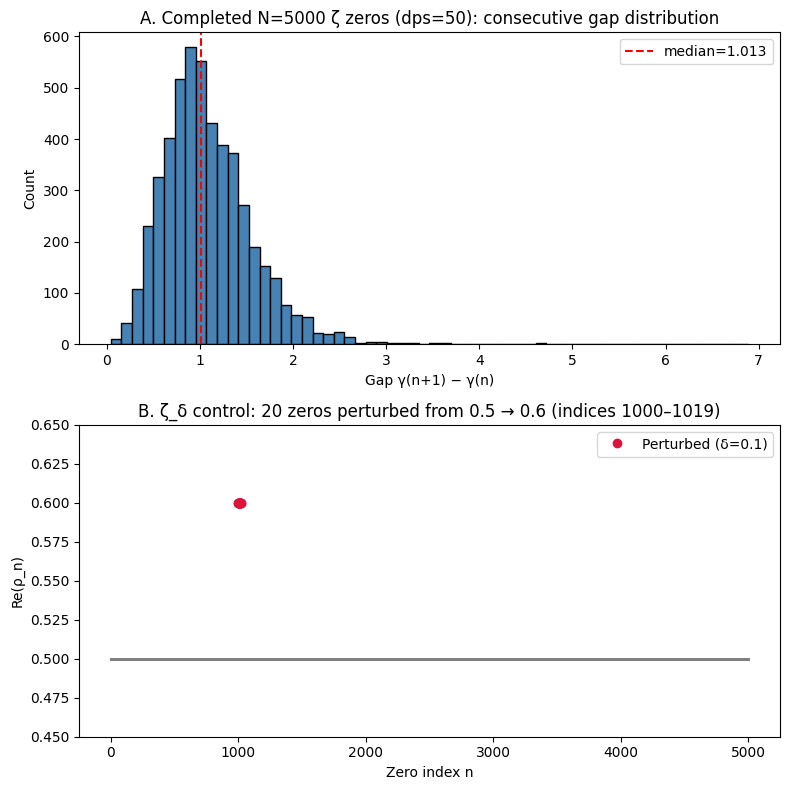

Saved zeta_zd_summary.png


In [9]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Panel A: distribution of gaps between consecutive zeros for N=5000 (showing successful completion)
gammas = np.array([float(s) for s in sorted_arr])
gaps = np.diff(gammas)
axes[0].hist(gaps, bins=60, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Gap γ(n+1) − γ(n)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'A. Completed N={len(gammas)} ζ zeros (dps=50): consecutive gap distribution')
axes[0].axvline(np.median(gaps), color='red', linestyle='--', label=f'median={np.median(gaps):.3f}')
axes[0].legend()

# Panel B: ζ_δ perturbation — show real part = 0.5 except indices 1000..1019 = 0.6
idx = np.arange(5000)
real_parts = np.array([float(zeta_delta_arr[i]['re']) for i in idx])
axes[1].plot(idx, real_parts, '.', markersize=2, color='gray')
mask = (idx >= 1000) & (idx <= 1019)
axes[1].plot(idx[mask], real_parts[mask], 'o', color='crimson', label='Perturbed (δ=0.1)')
axes[1].set_xlabel('Zero index n')
axes[1].set_ylabel('Re(ρ_n)')
axes[1].set_ylim(0.45, 0.65)
axes[1].set_title('B. ζ_δ control: 20 zeros perturbed from 0.5 → 0.6 (indices 1000–1019)')
axes[1].legend()

plt.tight_layout()
plt.savefig('zeta_zd_summary.png', dpi=120)
plt.show()
print("Saved zeta_zd_summary.png")
